In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 200
# Dark Mode Plots
plt.style.use('dark_background')
import corner
import ast

In [7]:
# Make the corner plot for the MCMC results
system_name = 'J2205'
model_ver = 'sie'
mcmc_samples_path = f'../{system_name}/mcmc/{model_ver}_mcmc.dat'
samples = pd.read_csv(mcmc_samples_path, delim_whitespace=True, header=None, names=['chi2', 'vel_disp', 'x', 'y', 'ellip', 'pa' ])


In [8]:
samples

,chi2,vel_disp,x,y,ellip,pa
0,0.786804,224.1179,-0.944243,-0.110300,0.379146,5.600988
1,1.080682,224.1577,-0.945007,-0.110954,0.379119,5.522485
2,2.275354,224.2154,-0.946493,-0.107668,0.382195,5.517750
3,5.730048,223.9734,-0.942561,-0.116204,0.382244,5.593540
4,4.254156,223.4752,-0.946252,-0.112272,0.383429,5.659121
...,...,...,...,...,...,...
2323,5.250433,224.5213,-0.951477,-0.107804,0.397413,5.454431
2324,7.827618,223.9959,-0.951434,-0.106802,0.405389,5.564069
2325,4.310256,223.7540,-0.956062,-0.113237,0.401924,5.537940
2326,9.754598,223.6916,-0.954370,-0.119769,0.399714,5.515789


In [9]:
masked_samples = samples.drop(columns=['chi2']).to_numpy()

In [10]:
# # Masked Samples with no accept column
# masked_samples = samples[samples['accept'] == 'accept'].copy()
# masked_samples = masked_samples.drop(columns=['accept', 'chi2']).to_numpy()
# masked_samples

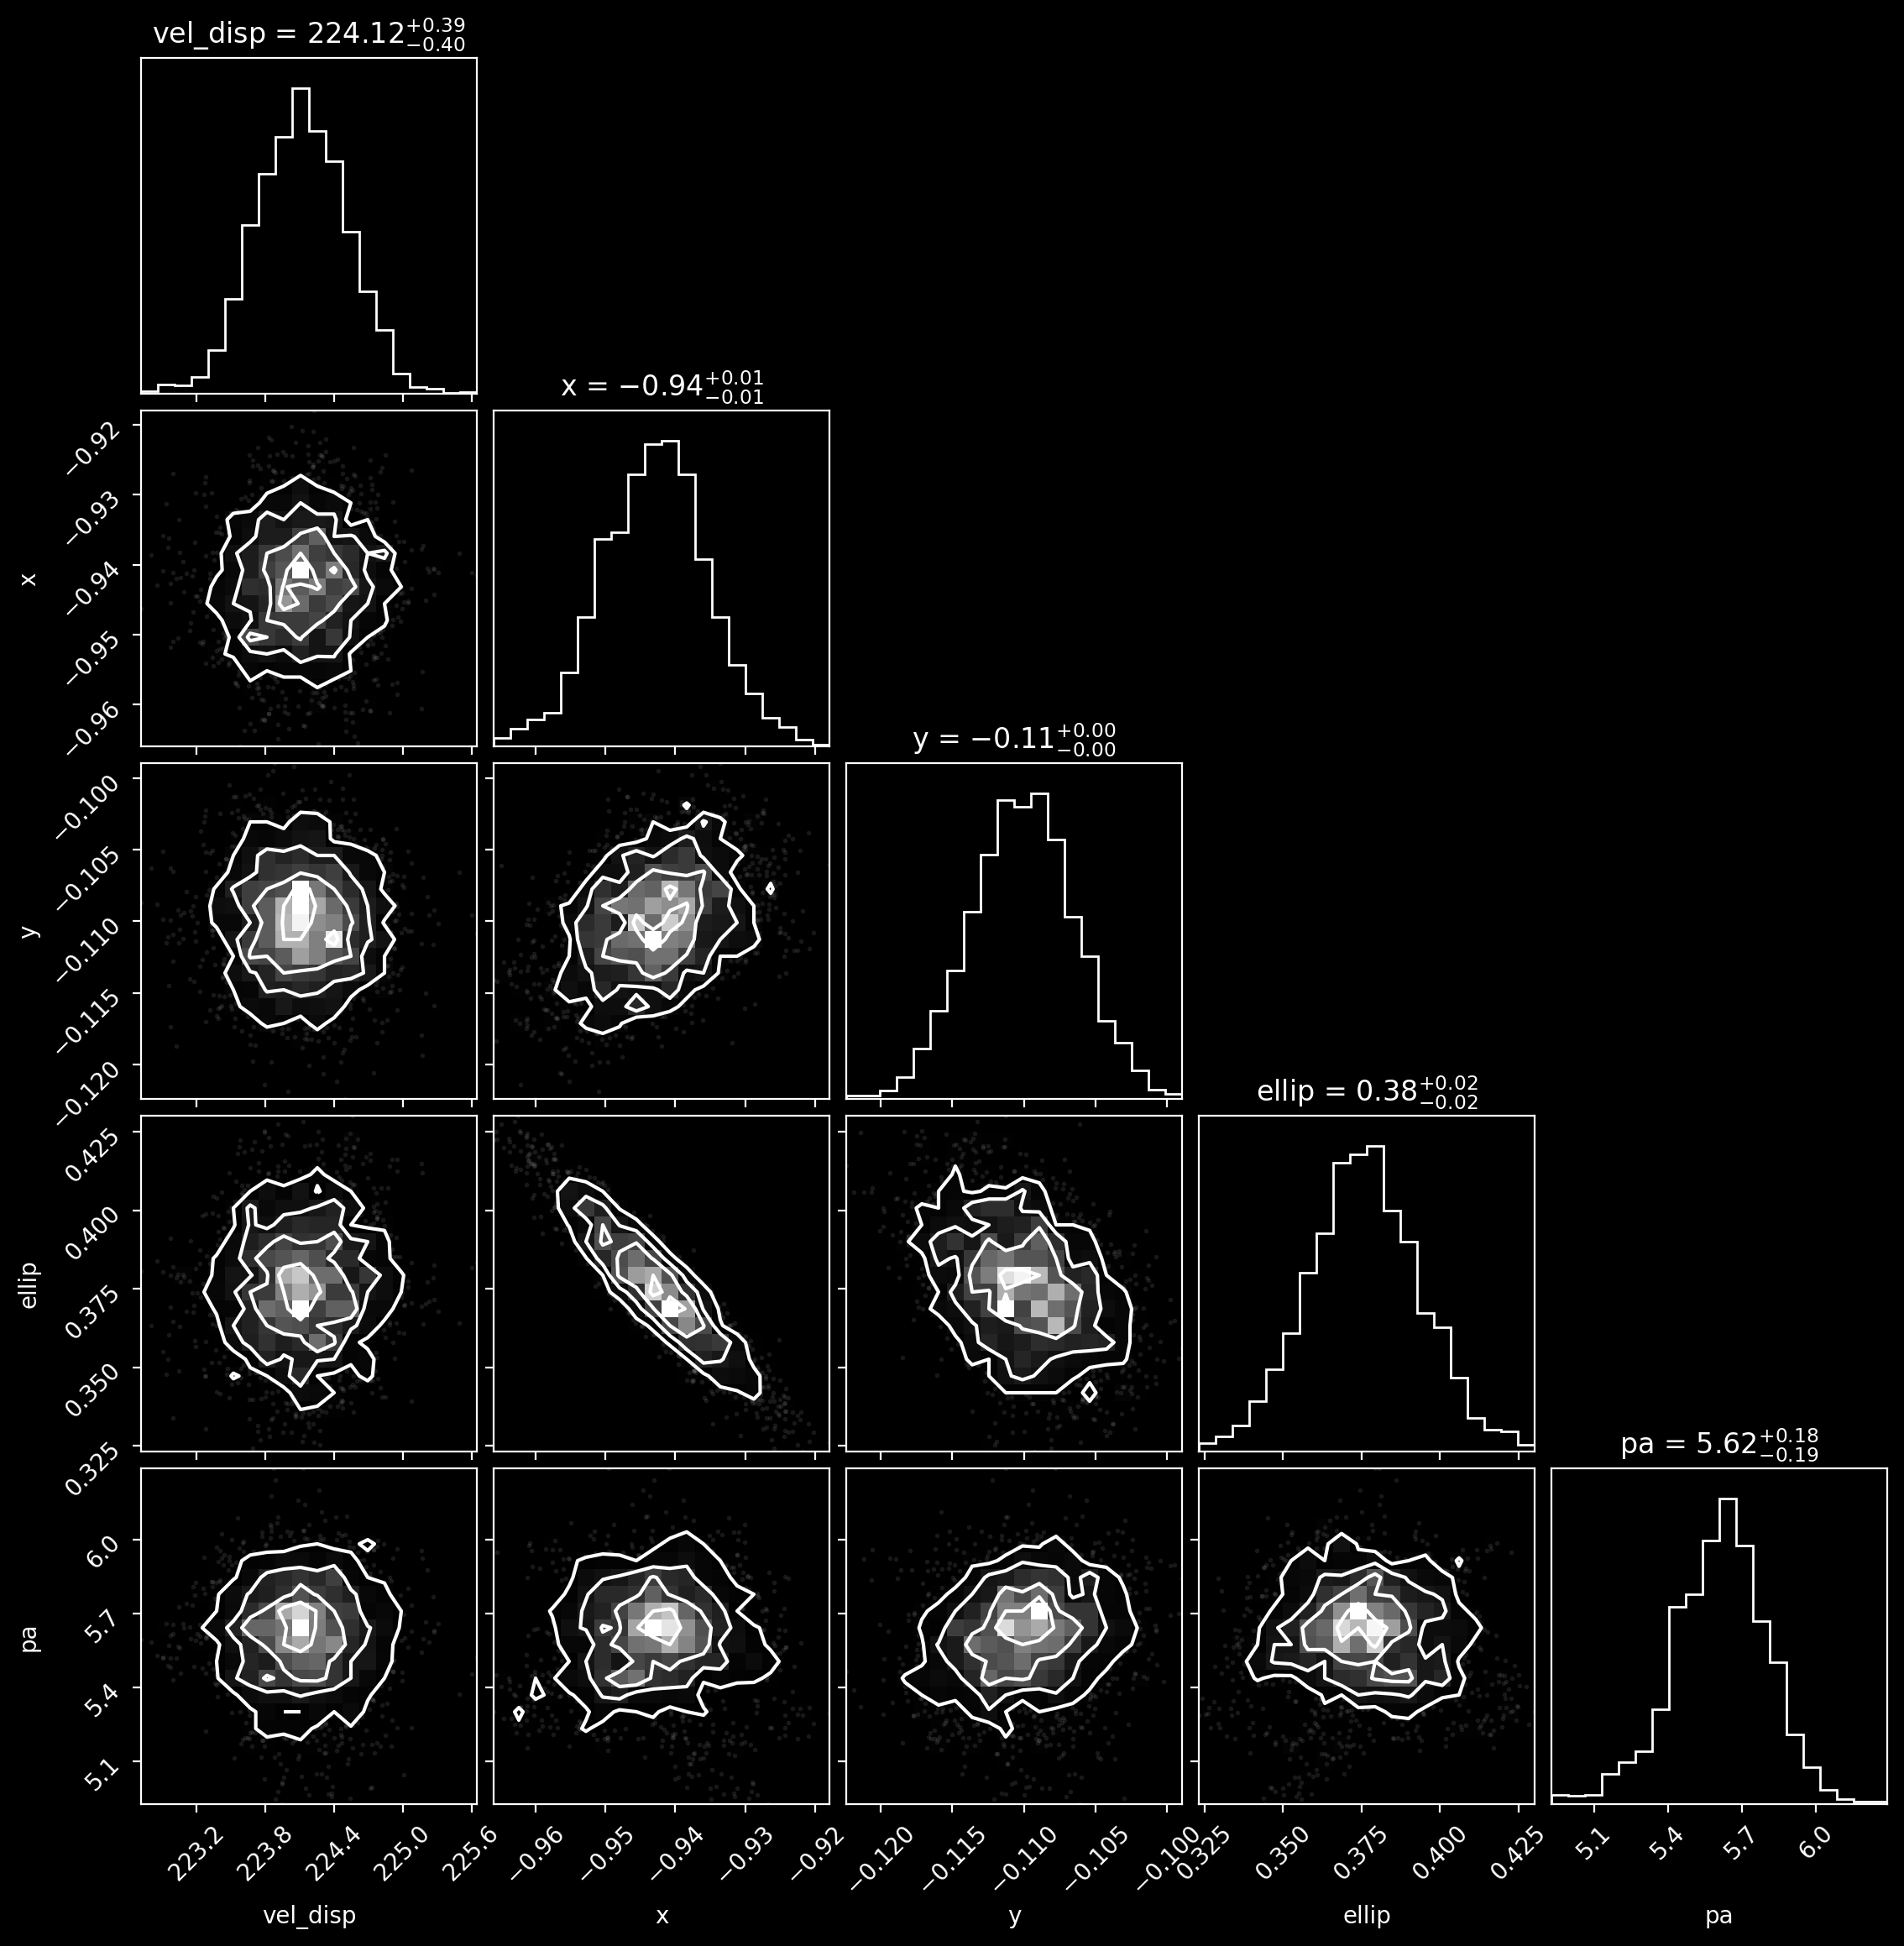

In [11]:
# Remove the first column when loading the samples, as it is the accepted/rejected column
labels = ['vel_disp', 'x', 'y', 'ellip', 'pa']
fig = corner.corner(masked_samples, labels=labels, show_titles=True)
plt.savefig(f'../{system_name}/mcmc/{model_ver}_corner.png')